In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [10]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

First let's see what is our data format.

In [11]:
heart_disease??

Type:        dotdict
String form:
{'data': {'ids': None, 'features':      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  t

In [12]:
type(heart_disease)

ucimlrepo.dotdict.dotdict

In [13]:
heart_disease.keys()

dict_keys(['data', 'metadata', 'variables'])

In [14]:
heart_disease.data.keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [15]:
heart_disease.metadata.keys()

dict_keys(['uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area', 'tasks', 'characteristics', 'num_instances', 'num_features', 'feature_types', 'demographics', 'target_col', 'index_col', 'has_missing_values', 'missing_values_symbol', 'year_of_dataset_creation', 'last_updated', 'dataset_doi', 'creators', 'intro_paper', 'additional_info'])

In [16]:
heart_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


In [17]:
heart_disease.data.original

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


So thal(3 = normal; 6 = fixed defect; 7 = reversable defect) and ca(number of major vessals) can be missing.


For the missing, let's replace them with the median value for that column for the whole dataset.

In [18]:
 pip install -Uqq waterfallcharts treeinterpreter dtreeviz==1.4.1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [19]:
from pandas.api.types import is_string_dtype, is_numeric_dtype, is_categorical_dtype
from fastai.tabular.all import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from dtreeviz.trees import *
from IPython.display import Image, display_svg, SVG

pd.options.display.max_rows = 20
pd.options.display.max_columns = 8

In [20]:
procs=[FillMissing]
dep_var='num'
cont,cat = cont_cat_split(heart_disease.data.original, dep_var=dep_var)

train_idx=[]
valid_idx=[]
for i in range(len(heart_disease.data.original)):
    include_in_valid=random.random()
    if include_in_valid <= 0.1:
        valid_idx.append(i)
    else:
        train_idx.append(i)

splits = (train_idx, valid_idx)
to = TabularPandas(heart_disease.data.original, procs, cat, cont, y_names=dep_var, splits=splits)

/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)
/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [21]:
to.show(100)

,sex,cp,fbs,restecg,exang,slope,ca_na,thal_na,age,trestbps,chol,thalach,oldpeak,ca,thal,num
0,1,1,1,2,0,3,False,False,63,145,233,150,2.3,0.0,6.0,0
1,1,4,0,2,1,2,False,False,67,160,286,108,1.5,3.0,3.0,2
2,1,4,0,2,1,2,False,False,67,120,229,129,2.6,2.0,7.0,1
4,0,2,0,2,0,1,False,False,41,130,204,172,1.4,0.0,3.0,0
5,1,2,0,0,0,1,False,False,56,120,236,178,0.8,0.0,3.0,0
7,0,4,0,0,1,1,False,False,57,120,354,163,0.6,0.0,3.0,0
8,1,4,0,2,0,2,False,False,63,130,254,147,1.4,1.0,7.0,2
9,1,4,1,2,1,3,False,False,53,140,203,155,3.1,0.0,7.0,1
10,1,4,0,0,0,2,False,False,57,140,192,148,0.4,0.0,6.0,0
11,0,2,0,2,0,2,False,False,56,140,294,153,1.3,0.0,3.0,0


In [22]:
save_pickle('to.pkl',to)

In [23]:
to = load_pickle('to.pkl')

In [24]:
xs,y = to.train.xs,to.train.y
valid_xs,valid_y = to.valid.xs,to.valid.y
print(y.value_counts(normalize=True).sort_index())
print(valid_y.value_counts(normalize=True).sort_index())

num
0    0.551601
1    0.177936
2    0.124555
3    0.103203
4    0.042705
Name: proportion, dtype: float64
num
0    0.409091
1    0.227273
2    0.045455
3    0.272727
4    0.045455
Name: proportion, dtype: float64


Once we train decision tree? How to classify?

For each sample, we can classify it's class to be the majority class in the leaf node it gets marked to.


Given that, we can use accuracy defined a proportions of correctly classified.

In [25]:
def misclassified(m, xs, y):
    preds=m.predict(xs)
    miscount=0
    for idx in range(len(preds)):
        if preds[idx]!=y.iloc[idx]:
            miscount+=1
    return miscount/len(preds)

In [26]:
m = DecisionTreeClassifier(max_leaf_nodes=4)
m.fit(xs, y);

In [27]:
print(misclassified(m, xs, y))
print(misclassified(m, valid_xs, valid_y))

0.3736654804270463
0.5909090909090909


In [28]:
!pip install -Uqq fastbook
import fastbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.5 MB/s eta 0:00:00


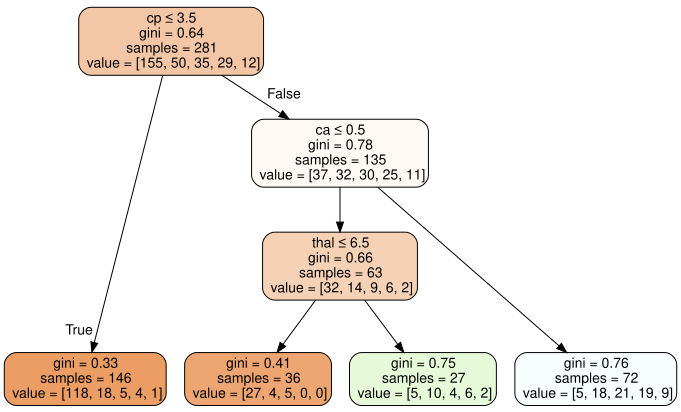

In [29]:
fastbook.setup_book()
from fastbook import *
draw_tree(m, xs, size=10, leaves_parallel=True, precision=2)

Let's try a decision tree without any configuration, this defaults to splitting until all leaves are pure. I fully expect this to overfit horribly.

In [30]:
m = DecisionTreeClassifier()
m.fit(xs, y);

In [31]:
print(misclassified(m, xs, y))
print(misclassified(m, valid_xs, valid_y))

0.0
0.7272727272727273


While the training loss is very low, the validation is very high, as we predicted there is lot of overfitting here.

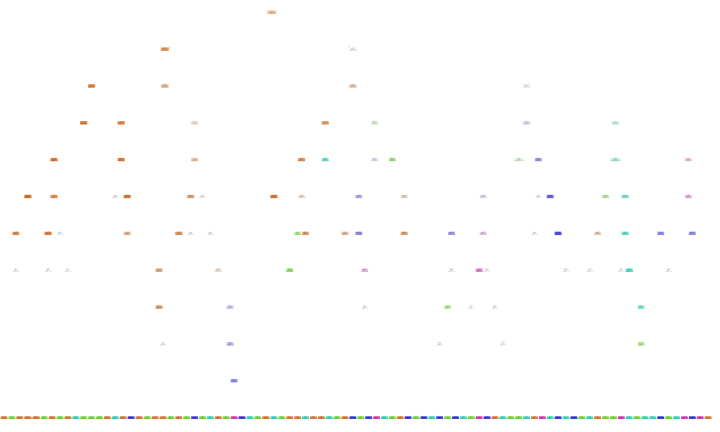

In [32]:

draw_tree(m, xs, size=10, leaves_parallel=True, precision=2)

In [33]:
import pandas as pd

n_nodes = m.tree_.node_count
children_left = m.tree_.children_left
children_right = m.tree_.children_right
values = m.tree_.value

# Find node IDs that are leaves (where both children are -1)
leaf_ids = [i for i in range(n_nodes) if children_left[i] == children_right[i]]

leaf_stats = []
for leaf in leaf_ids:
    leaf_stats.append({
        'Leaf ID': leaf,
        'Samples': m.tree_.n_node_samples[leaf],
        'Class Distribution': values[leaf][0] 
    })

pd.DataFrame(leaf_stats)

,Leaf ID,Samples,Class Distribution
0,7,5,"[1.0, 0.0, 0.0, 0.0, 0.0]"
1,9,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
2,10,1,"[1.0, 0.0, 0.0, 0.0, 0.0]"
3,11,61,"[1.0, 0.0, 0.0, 0.0, 0.0]"
4,14,12,"[1.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...
85,171,1,"[0.0, 0.0, 1.0, 0.0, 0.0]"
86,174,2,"[0.0, 0.0, 0.0, 0.0, 1.0]"
87,176,2,"[0.0, 0.0, 0.0, 1.0, 0.0]"
88,177,1,"[0.0, 0.0, 0.0, 0.0, 1.0]"


Let's try random forests!

In [34]:
import numpy as np

def run_repeated_experiments(n_runs=10, state_offset=0,**kwargs):
    """
    Trains a Random Forest multiple times with varying random seeds 
    and prints the aggregated summary statistics.
    """
    print(f"Parameters: {kwargs}")
    print(f"Runs: {n_runs}")
    train_errors = []
    valid_errors = []
    oob_scores = []
    
    for i in range(n_runs):
        # Initialize model with a different random_state for each run
        m = RandomForestClassifier(
            n_jobs=-1, 
            **kwargs,
            oob_score=True,
            random_state=i + state_offset # Varies from 0 to n_runs-1
        )
        
        # Fit model
        m.fit(xs, y)
        
        # Calculate & Store Statistics
        train_errors.append(misclassified(m, xs, y))
        valid_errors.append(misclassified(m, valid_xs, valid_y))
        oob_scores.append(m.oob_score_)
        
    # Aggregate Summary Table
    stats = pd.DataFrame({
        'Metric': ['Train Misclassification', 'Valid Misclassification', 'OOB Score'],
        'Mean': [np.mean(train_errors), np.mean(valid_errors), np.mean(oob_scores)],
        'Std Dev': [np.std(train_errors), np.std(valid_errors), np.std(oob_scores)]
    })
    
    # Formatting for cleaner display
    stats['Mean'] = stats['Mean'].apply(lambda x: f"{x:.4f}")
    stats['Std Dev'] = stats['Std Dev'].apply(lambda x: f"± {x:.4f}")
    
    display(stats)
    
    return stats

Let's try tweaking the number of random forests

In [35]:
stats_1 = run_repeated_experiments(n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


,Metric,Mean,Std Dev
0,Train Misclassification,0.3039,± 0.0077
1,Valid Misclassification,0.5955,± 0.0136
2,OOB Score,0.5915,± 0.0065


In [36]:
stats_1 = run_repeated_experiments(n_estimators=100, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 100, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


,Metric,Mean,Std Dev
0,Train Misclassification,0.3028,± 0.0117
1,Valid Misclassification,0.5909,± 0.0000
2,OOB Score,0.5890,± 0.0090


In [37]:
stats_1 = run_repeated_experiments(n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3324,± 0.0235
1,Valid Misclassification,0.5818,± 0.0273
2,OOB Score,0.5651,± 0.0205


The training misclassification went up between 4 and 40, but not from 40 to 100.

The validation misclassification stays the same between 40 and 100, but paradoxically goes between going from 4 to 40.

The OOB score went up between 4 and 40, however, stayed the same as we scaled to 100.

Conclusion: 

40 -> 100 does not yield any quality benefits.

Validation misclassification has higher variance since it is smaller and hence we observe the abnormal result.

Let's repeat the same experiment with higher number of runs to see validation misclassification is a pattern or just noise.

In [38]:
stats_1 = run_repeated_experiments(n_runs=50, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
stats_1 = run_repeated_experiments(n_runs=50, n_estimators=100, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
stats_1 = run_repeated_experiments(n_runs=50, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.3078,± 0.0099
1,Valid Misclassification,0.5927,± 0.0181
2,OOB Score,0.5917,± 0.0110


Parameters: {'n_estimators': 100, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.3021,± 0.0099
1,Valid Misclassification,0.5909,± 0.0000
2,OOB Score,0.5895,± 0.0104


Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3342,± 0.0194
1,Valid Misclassification,0.5836,± 0.0484
2,OOB Score,0.5675,± 0.0194


We note that the 4 tree random forests is still better in validation misclassification but note that it's variance is higher

It is also worse in OOB score and training misclassification.

Maybe it is the following cause:
a) The first 10 random_state are just, by chance, well suited for the 4 tree case and biasing the results.

We can see if (a) is the case by trying a different set of seeds and seeing that brings it up.

In [39]:
stats_1 = run_repeated_experiments(n_runs=10, state_offset=100, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
stats_1 = run_repeated_experiments(n_runs=50, state_offset=100, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3359,± 0.0147
1,Valid Misclassification,0.5682,± 0.0366
2,OOB Score,0.5633,± 0.0152


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3367,± 0.0170
1,Valid Misclassification,0.5682,± 0.0555
2,OOB Score,0.5651,± 0.0190


Nope it still seems to be winning on the validation misclasification. This might be something else. We will come back here later and try to improvise our model first.

How do we even improve this?
i) We know we cannot throw more forests.
ii) Would it be worth trying to split more - Let's try that

In [40]:
stats_1 = run_repeated_experiments(n_runs=50, state_offset=100, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.05)


Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.05}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.2183,± 0.0140
1,Valid Misclassification,0.5845,± 0.0273
2,OOB Score,0.5878,± 0.0132


Okay this is probably going in overfitting since validation error went up and OOB also went up, while training error went down.
This is probably not the knob to tweak.

In [41]:
stats_1 = run_repeated_experiments(n_runs=50, state_offset=100, n_estimators=40, max_samples=0.75, max_features=0.3, min_samples_split=0.1)


Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.3, 'min_samples_split': 0.1}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.3206,± 0.0138
1,Valid Misclassification,0.5909,± 0.0000
2,OOB Score,0.5882,± 0.0103


Okay. I am using a mix of OOB score and validation score when the validation set is too small. Let's instead use K-fold stratergy per evaluation. The tradeoff is:

Slower training loop but we have less variance in validation error. This directly gives less variance in our model selection stratergy.

In [70]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

def run_kfold_experiments(X, y, n_splits=5, n_runs=1, state_offset=0, **kwargs):
    """
    Trains Random Forest using K-Fold cross-validation across multiple runs.
    Tracks Training Error, Validation Error, and OOB Scores.
    """
    print(f"Parameters: {kwargs}")
    print(f"Strategy: {n_splits}-Fold CV | Runs: {n_runs}")
    
    train_errors = []
    val_errors = []
    oob_scores = []
    
    for run in range(n_runs):
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=run + state_offset)
        
        run_train_errors = []
        run_val_errors = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            m = RandomForestClassifier(
                n_jobs=-1, 
                oob_score=True,
                random_state=run + state_offset,
                **kwargs
            )
            
            m.fit(X_train, y_train.values.ravel())
            
            # Record Training Error
            train_err = 1 - m.score(X_train, y_train)
            run_train_errors.append(train_err)
            
            # Record Validation Error
            val_err = 1 - m.score(X_val, y_val)
            run_val_errors.append(val_err)
            
            oob_scores.append(m.oob_score_)
            
        train_errors.extend(run_train_errors)
        val_errors.extend(run_val_errors)
        
        print(f"Run {run + 1} complete | Avg Train Err: {np.mean(run_train_errors):.4f} | Avg Val Err: {np.mean(run_val_errors):.4f}")

    # Final Aggregated Statistics
    print("-" * 30)
    print(f"Final Mean Train Error:      {np.mean(train_errors):.4f}")
    print(f"Final Mean Validation Error: {np.mean(val_errors):.4f}")
    print(f"Final Mean OOB Score:        {np.mean(oob_scores):.4f}")
    print(f"Generalization Gap:          {np.mean(val_errors) - np.mean(train_errors):.4f}")
    print(f"Error Standard Deviation:    {np.std(val_errors):.4f}")
    
    return train_errors, val_errors, oob_scores

In [43]:
# Concatenate X_train and X_val
X_full = pd.concat([xs, valid_xs], axis=0).reset_index(drop=True)
y_full = pd.concat([y, valid_y], axis=0).reset_index(drop=True)

Rerunning our first experiments with k-fold.

In [71]:
run_kfold_experiments(X_full, y_full, n_runs=10, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
run_kfold_experiments(X_full, y_full, n_runs=10, n_estimators=100, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
run_kfold_experiments(X_full, y_full, n_runs=10, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)


Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 complete | Avg Train Err: 0.3143 | Avg Val Err: 0.4161
Run 2 complete | Avg Train Err: 0.3061 | Avg Val Err: 0.4227
Run 3 complete | Avg Train Err: 0.3036 | Avg Val Err: 0.4089
Run 4 complete | Avg Train Err: 0.3036 | Avg Val Err: 0.4192
Run 5 complete | Avg Train Err: 0.3086 | Avg Val Err: 0.4454
Run 6 complete | Avg Train Err: 0.3094 | Avg Val Err: 0.4457
Run 7 complete | Avg Train Err: 0.3003 | Avg Val Err: 0.4224
Run 8 complete | Avg Train Err: 0.2995 | Avg Val Err: 0.4489
Run 9 complete | Avg Train Err: 0.3094 | Avg Val Err: 0.4192
Run 10 complete | Avg Train Err: 0.2995 | Avg Val Err: 0.4160
------------------------------
Final Mean Train Error:      0.3054
Final Mean Validation Error: 0.4264
Final Mean OOB Score:        0.5764
Generalization Gap:          0.1210
Error Standard Deviation:    0.0538
Parameters: {'n_estimators': 100, 'max_samples

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

Run 1 complete | Avg Train Err: 0.3416 | Avg Val Err: 0.4130


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Run 2 complete | Avg Train Err: 0.3251 | Avg Val Err: 0.4128


...

Run 8 complete | Avg Train Err: 0.3358 | Avg Val Err: 0.4356


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

Run 9 complete | Avg Train Err: 0.3482 | Avg Val Err: 0.4325
Run 10 complete | Avg Train Err: 0.3473 | Avg Val Err: 0.4361
------------------------------
Final Mean Train Error:      0.3433
Final Mean Validation Error: 0.4269
Final Mean OOB Score:        0.5498
Generalization Gap:          0.0835
Error Standard Deviation:    0.0508


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


([0.3099173553719008,
  0.3677685950413223,
  0.35123966942148765,
  0.34156378600823045,
  0.3374485596707819,
  0.32644628099173556,
  0.3305785123966942,
  0.3223140495867769,
  0.3168724279835391,
  0.3292181069958847,
  0.33884297520661155,
  0.3553719008264463,
  0.33884297520661155,
  0.32098765432098764,
  0.34156378600823045,
  0.3305785123966942,
  0.3223140495867769,
  0.3677685950413223,
  0.3251028806584362,
  0.33333333333333337,
  0.3471074380165289,
  0.3471074380165289,
  0.37603305785123964,
  0.37860082304526754,
  0.33333333333333337,
  0.3553719008264463,
  0.3677685950413223,
  0.33884297520661155,
  0.31275720164609055,
  0.3539094650205762,
  0.3471074380165289,
  0.3553719008264463,
  0.3801652892561983,
  0.3539094650205762,
  0.3539094650205762,
  0.30165289256198347,
  0.3347107438016529,
  0.3429752066115702,
  0.3374485596707819,
  0.36213991769547327,
  0.35123966942148765,
  0.33884297520661155,
  0.35123966942148765,
  0.345679012345679,
  0.35390946502

Finally we can see a pattern that we expect emerging. The average valdation loss is lower for more trees.


Let's try to understand the features
a) Plot the most important feature.




In [45]:
 m = RandomForestClassifier(
            n_jobs=-1,
     n_estimators=40,
     max_samples=0.75,
     max_features=0.5, 
     min_samples_split=0.1,
            oob_score=True,
        )

m.fit(X_full, y_full)
def rf_feat_importance(m, df):
    return pd.DataFrame({'cols':df.columns, 'imp':m.feature_importances_}
                       ).sort_values('imp', ascending=False)

fi = rf_feat_importance(m, X_full)
fi[:13]

,cols,imp
14,thal,0.198366
1,cp,0.195707
13,ca,0.159998
12,oldpeak,0.144769
11,thalach,0.089058
9,trestbps,0.049510
4,exang,0.046275
8,age,0.040712
10,chol,0.036059
5,slope,0.022641


Let's maybe keep the first 5 and see if that helps our model



In [72]:

top_5_features = ['thal', 'cp', 'ca', 'oldpeak', 'thalach']

# Create the subset
X_subset = X_full[top_5_features]

# 3. Run the experiment
run_kfold_experiments(X_subset, y_full, n_splits=5, n_runs=10, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 complete | Avg Train Err: 0.3309 | Avg Val Err: 0.4196
Run 2 complete | Avg Train Err: 0.3300 | Avg Val Err: 0.4128
Run 3 complete | Avg Train Err: 0.3259 | Avg Val Err: 0.3925
Run 4 complete | Avg Train Err: 0.3243 | Avg Val Err: 0.4092
Run 5 complete | Avg Train Err: 0.3325 | Avg Val Err: 0.4453
Run 6 complete | Avg Train Err: 0.3424 | Avg Val Err: 0.4093
Run 7 complete | Avg Train Err: 0.3267 | Avg Val Err: 0.4157
Run 8 complete | Avg Train Err: 0.3251 | Avg Val Err: 0.4157
Run 9 complete | Avg Train Err: 0.3432 | Avg Val Err: 0.4127
Run 10 complete | Avg Train Err: 0.3334 | Avg Val Err: 0.4126
------------------------------
Final Mean Train Error:      0.3314
Final Mean Validation Error: 0.4146
Final Mean OOB Score:        0.5796
Generalization Gap:          0.0831
Error Standard Deviation:    0.0501


([0.31404958677685946,
  0.3471074380165289,
  0.32644628099173556,
  0.33333333333333337,
  0.33333333333333337,
  0.3429752066115702,
  0.33884297520661155,
  0.3223140495867769,
  0.3251028806584362,
  0.32098765432098764,
  0.3305785123966942,
  0.31404958677685946,
  0.30578512396694213,
  0.3292181069958847,
  0.34979423868312753,
  0.3347107438016529,
  0.3223140495867769,
  0.3223140495867769,
  0.308641975308642,
  0.33333333333333337,
  0.3099173553719008,
  0.33884297520661155,
  0.3223140495867769,
  0.3662551440329218,
  0.3251028806584362,
  0.35123966942148765,
  0.3429752066115702,
  0.3305785123966942,
  0.3292181069958847,
  0.3580246913580247,
  0.32644628099173556,
  0.3099173553719008,
  0.3471074380165289,
  0.308641975308642,
  0.34156378600823045,
  0.31404958677685946,
  0.32644628099173556,
  0.3471074380165289,
  0.3251028806584362,
  0.31275720164609055,
  0.359504132231405,
  0.3471074380165289,
  0.3347107438016529,
  0.34979423868312753,
  0.3251028806584

Model is just as good but not better.


Okay so we have 4 class classification, 330 rows, and we are able to get 60% accuracy on our validation set. Couple things that could potentially increase our accuracy:

a) Change the problem - Instead of predicting between 0-4, make it a binary classification problem of whether there is heart disease(>0 class) or not. The reasoning behind why this might increase our accuracy is because the original prediction is a superset of this prediction(predicting whether there is heart disease and it's severity).

b) Try different models - Random forests for this dataset is unable to reach a certain complexity. We potentially need something would be able to but without the variance exploring(not a neural net, maybe boosting in random forests).

Playing with gradient boosting

In [73]:
from sklearn.ensemble import GradientBoostingClassifier


def run_kfold_gradient_boosted_experiments(X, y, n_splits=5, n_runs=1, state_offset=0, **kwargs):
    """
    Trains Random Forest using K-Fold cross-validation across multiple runs.
    """
    print(f"Parameters: {kwargs}")
    print(f"Strategy: {n_splits}-Fold CV | Runs: {n_runs}")
    all_train_errors = []
    all_val_errors = []
    
    for run in range(n_runs):
        run_train_errors = []
        run_val_errors = []
        # Initialize KFold with a seed that changes per run
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=run + state_offset)
        
        run_errors = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            # Split using iloc for pandas compatibility
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Initialize model
            m = GradientBoostingClassifier(
                random_state=run + state_offset,
                **kwargs
            )
            
            # Fit and record metrics
            m.fit(X_train, y_train)
            # Record Training Error (Loss)
            train_err = 1 - m.score(X_train, y_train)
            run_train_errors.append(train_err)
            
            # Record Validation Error
            val_err = 1 - m.score(X_val, y_val)
            run_val_errors.append(val_err)
            
        all_train_errors.extend(run_train_errors)
        all_val_errors.extend(run_val_errors)
        
        print(f"Run {run + 1} | Train Err: {np.mean(run_train_errors):.4f} | Val Err: {np.mean(run_val_errors):.4f}")

    print("-" * 30)
    print(f"Final Mean Train Error: {np.mean(all_train_errors):.4f}")
    print(f"Final Mean Valid Error: {np.mean(all_val_errors):.4f}")
    print(f"Generalization Gap:     {np.mean(all_val_errors) - np.mean(all_train_errors):.4f}")
    
    return all_val_errors

In [74]:
#higher subsample gives us lower bias but higher variance
#higher estimators gives us lower bias(usually)
run_kfold_gradient_boosted_experiments(X_full, y_full, n_runs=10, n_estimators=100, subsample=1.0, max_features=1.0, min_samples_split=0.1)
#lower subsample gives us higher bias but lower variance 
run_kfold_gradient_boosted_experiments(X_full, y_full, n_runs=10, n_estimators=40, subsample=0.75, max_features=0.5, min_samples_split=0.1)



Parameters: {'n_estimators': 100, 'subsample': 1.0, 'max_features': 1.0, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 | Train Err: 0.0016 | Val Err: 0.4625
Run 2 | Train Err: 0.0000 | Val Err: 0.4391
Run 3 | Train Err: 0.0000 | Val Err: 0.4552
Run 4 | Train Err: 0.0008 | Val Err: 0.4754
Run 5 | Train Err: 0.0008 | Val Err: 0.4717
Run 6 | Train Err: 0.0016 | Val Err: 0.4390
Run 7 | Train Err: 0.0008 | Val Err: 0.4556
Run 8 | Train Err: 0.0008 | Val Err: 0.4685
Run 9 | Train Err: 0.0008 | Val Err: 0.4525
Run 10 | Train Err: 0.0000 | Val Err: 0.4557
------------------------------
Final Mean Train Error: 0.0007
Final Mean Valid Error: 0.4575
Generalization Gap:     0.4568
Parameters: {'n_estimators': 40, 'subsample': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 | Train Err: 0.0734 | Val Err: 0.4359
Run 2 | Train Err: 0.0668 | Val Err: 0.4390
Run 3 | Train Err: 0.0710 | Val Err: 0.4387
Run 4 | Train Err: 0.0767 | Val Err: 0.4357

[0.47540983606557374,
 0.3770491803278688,
 0.3770491803278688,
 0.44999999999999996,
 0.5,
 0.360655737704918,
 0.4590163934426229,
 0.47540983606557374,
 0.4666666666666667,
 0.43333333333333335,
 0.4590163934426229,
 0.4426229508196722,
 0.47540983606557374,
 0.4833333333333333,
 0.33333333333333337,
 0.3770491803278688,
 0.4426229508196722,
 0.4590163934426229,
 0.4833333333333333,
 0.41666666666666663,
 0.4590163934426229,
 0.4098360655737705,
 0.4918032786885246,
 0.35,
 0.44999999999999996,
 0.360655737704918,
 0.4426229508196722,
 0.4590163934426229,
 0.43333333333333335,
 0.4833333333333333,
 0.47540983606557374,
 0.5081967213114754,
 0.3114754098360656,
 0.41666666666666663,
 0.4666666666666667,
 0.5081967213114754,
 0.4590163934426229,
 0.39344262295081966,
 0.5166666666666666,
 0.4,
 0.3278688524590164,
 0.42622950819672134,
 0.42622950819672134,
 0.44999999999999996,
 0.4833333333333333,
 0.3770491803278688,
 0.39344262295081966,
 0.4426229508196722,
 0.4833333333333333,
 

In [75]:
run_kfold_gradient_boosted_experiments(X_full, y_full, n_runs=10, n_estimators=100, subsample=0.75, max_features=0.5, min_samples_split=0.1)


Parameters: {'n_estimators': 100, 'subsample': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 | Train Err: 0.0008 | Val Err: 0.4227
Run 2 | Train Err: 0.0016 | Val Err: 0.4457
Run 3 | Train Err: 0.0025 | Val Err: 0.4586
Run 4 | Train Err: 0.0025 | Val Err: 0.4488
Run 5 | Train Err: 0.0016 | Val Err: 0.4518
Run 6 | Train Err: 0.0025 | Val Err: 0.4225
Run 7 | Train Err: 0.0016 | Val Err: 0.4454
Run 8 | Train Err: 0.0000 | Val Err: 0.4422
Run 9 | Train Err: 0.0008 | Val Err: 0.4525
Run 10 | Train Err: 0.0033 | Val Err: 0.4358
------------------------------
Final Mean Train Error: 0.0017
Final Mean Valid Error: 0.4426
Generalization Gap:     0.4409


[0.4426229508196722,
 0.39344262295081966,
 0.360655737704918,
 0.44999999999999996,
 0.4666666666666667,
 0.3770491803278688,
 0.39344262295081966,
 0.5245901639344263,
 0.5,
 0.43333333333333335,
 0.4590163934426229,
 0.4426229508196722,
 0.5245901639344263,
 0.5166666666666666,
 0.35,
 0.42622950819672134,
 0.47540983606557374,
 0.4590163934426229,
 0.5166666666666666,
 0.3666666666666667,
 0.540983606557377,
 0.3770491803278688,
 0.540983606557377,
 0.33333333333333337,
 0.4666666666666667,
 0.39344262295081966,
 0.42622950819672134,
 0.42622950819672134,
 0.44999999999999996,
 0.41666666666666663,
 0.5081967213114754,
 0.540983606557377,
 0.34426229508196726,
 0.4,
 0.43333333333333335,
 0.4426229508196722,
 0.47540983606557374,
 0.4098360655737705,
 0.4833333333333333,
 0.4,
 0.3770491803278688,
 0.4426229508196722,
 0.42622950819672134,
 0.5,
 0.5166666666666666,
 0.3770491803278688,
 0.4426229508196722,
 0.4426229508196722,
 0.4666666666666667,
 0.44999999999999996]

The training error is way too small. We are overfitting. Let's do early stopping and see if that helps.



In [78]:
run_kfold_gradient_boosted_experiments(X_full, y_full, n_runs=10, n_estimators=100, subsample=0.75, max_features=0.5, min_samples_split=0.1, n_iter_no_change=7, validation_fraction=0.3)


Parameters: {'n_estimators': 100, 'subsample': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1, 'n_iter_no_change': 7, 'validation_fraction': 0.3}
Strategy: 5-Fold CV | Runs: 10
Run 1 | Train Err: 0.2038 | Val Err: 0.4130
Run 2 | Train Err: 0.2252 | Val Err: 0.4260
Run 3 | Train Err: 0.1980 | Val Err: 0.4321
Run 4 | Train Err: 0.2087 | Val Err: 0.4258
Run 5 | Train Err: 0.2104 | Val Err: 0.4189
Run 6 | Train Err: 0.1823 | Val Err: 0.4160
Run 7 | Train Err: 0.1906 | Val Err: 0.4488
Run 8 | Train Err: 0.1996 | Val Err: 0.4423
Run 9 | Train Err: 0.1758 | Val Err: 0.4061
Run 10 | Train Err: 0.1758 | Val Err: 0.4160
------------------------------
Final Mean Train Error: 0.1970
Final Mean Valid Error: 0.4245
Generalization Gap:     0.2275


[0.42622950819672134,
 0.3114754098360656,
 0.3770491803278688,
 0.44999999999999996,
 0.5,
 0.29508196721311475,
 0.39344262295081966,
 0.5245901639344263,
 0.4833333333333333,
 0.43333333333333335,
 0.5081967213114754,
 0.42622950819672134,
 0.4426229508196722,
 0.4833333333333333,
 0.30000000000000004,
 0.3278688524590164,
 0.4426229508196722,
 0.4918032786885246,
 0.4833333333333333,
 0.3833333333333333,
 0.4590163934426229,
 0.39344262295081966,
 0.47540983606557374,
 0.33333333333333337,
 0.43333333333333335,
 0.3770491803278688,
 0.4098360655737705,
 0.4098360655737705,
 0.44999999999999996,
 0.43333333333333335,
 0.5245901639344263,
 0.540983606557377,
 0.29508196721311475,
 0.43333333333333335,
 0.44999999999999996,
 0.4918032786885246,
 0.4590163934426229,
 0.360655737704918,
 0.5,
 0.4,
 0.3114754098360656,
 0.4426229508196722,
 0.42622950819672134,
 0.41666666666666663,
 0.43333333333333335,
 0.39344262295081966,
 0.4098360655737705,
 0.39344262295081966,
 0.449999999999999

In [79]:
run_kfold_gradient_boosted_experiments(X_full, y_full, n_runs=10, n_estimators=100, subsample=0.75, max_features=0.5, min_samples_split=0.1, n_iter_no_change=7, validation_fraction=0.3)


Parameters: {'n_estimators': 100, 'subsample': 0.75, 'max_features': 1.0, 'min_samples_split': 0.1, 'n_iter_no_change': 7, 'validation_fraction': 0.3}
Strategy: 5-Fold CV | Runs: 10
Run 1 | Train Err: 0.2203 | Val Err: 0.4162
Run 2 | Train Err: 0.2146 | Val Err: 0.4457
Run 3 | Train Err: 0.2005 | Val Err: 0.4321
Run 4 | Train Err: 0.1856 | Val Err: 0.4291
Run 5 | Train Err: 0.1972 | Val Err: 0.4255
Run 6 | Train Err: 0.1790 | Val Err: 0.4093
Run 7 | Train Err: 0.1840 | Val Err: 0.4323
Run 8 | Train Err: 0.1972 | Val Err: 0.4521
Run 9 | Train Err: 0.1840 | Val Err: 0.3961
Run 10 | Train Err: 0.2104 | Val Err: 0.4426
------------------------------
Final Mean Train Error: 0.1973
Final Mean Valid Error: 0.4281
Generalization Gap:     0.2308


[0.42622950819672134,
 0.3114754098360656,
 0.39344262295081966,
 0.43333333333333335,
 0.5166666666666666,
 0.3278688524590164,
 0.4590163934426229,
 0.5081967213114754,
 0.4833333333333333,
 0.44999999999999996,
 0.47540983606557374,
 0.4426229508196722,
 0.4426229508196722,
 0.4833333333333333,
 0.31666666666666665,
 0.360655737704918,
 0.4426229508196722,
 0.47540983606557374,
 0.4833333333333333,
 0.3833333333333333,
 0.4426229508196722,
 0.42622950819672134,
 0.4918032786885246,
 0.31666666666666665,
 0.44999999999999996,
 0.3770491803278688,
 0.39344262295081966,
 0.4426229508196722,
 0.41666666666666663,
 0.41666666666666663,
 0.4918032786885246,
 0.5245901639344263,
 0.2786885245901639,
 0.43333333333333335,
 0.43333333333333335,
 0.5245901639344263,
 0.4590163934426229,
 0.39344262295081966,
 0.4833333333333333,
 0.4,
 0.3114754098360656,
 0.4098360655737705,
 0.4426229508196722,
 0.3833333333333333,
 0.43333333333333335,
 0.3770491803278688,
 0.39344262295081966,
 0.45901639